### DS 3026 Final Project - Section 4
# Part 4: Bayesian Analysis

**Inferential Question:** Does the home team have an advantage in NBA games? If it exists, has the home-court advantage changed in the modern era (post-2018)?

<!-- What is the true long-run probability that the home team wins an NBA game? -->

**Parameter of Interest:** π = true home-win probability (treat as random variable and is originally unknown)

**Model:** Each NBA game is modeled as a Bernoulli trial with success probability π. The total number of home wins follows a Binomial distribution.

**Prior:** We assign a Beta(1,1) prior to π, representing a uniform prior belief.

**Posterior:** After observing the data, the posterior becomes = (π | data ~ Beta(1 + wins, 1 + losses))

In [65]:
#import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from scipy.stats import beta

### Data Loading

In [66]:
# courtesy of section 3 code
game_df = pd.read_csv('./data/game_df.csv')

#Filter to Regular Season games only for clean inference
reg_season = game_df[game_df['season_type'] == 'Regular Season'].copy()

#setting up the target of win and loss
# Binary outcome: 1 = home win, 0 = home loss
reg_season['home_win'] = (reg_season['wl_home'] == 'W').astype(int)
reg_season['pt_diff']  = reg_season['pts_home'] - reg_season['pts_away']

# Extract season year from season_id, which is found in last four digits
reg_season['season_year'] = reg_season['season_id'].astype(str).str[-4:].astype(int)

#creating key variables for the total games, wins and probability
n_total  = len(reg_season)
n_wins   = reg_season['home_win'].sum()
p_hat    = n_wins / n_total

## POSTERIOR INFERENCE

### Model Training (Beta-Binomial)

- Why beta-binomial? : outcome is binary with 1 (home win) and 0 (home loss)
- Unknown parameter (π): the true home-win probability

In [67]:
n_losses = n_total - n_wins

# prior: Beta(1,1) - beta binomial - This is a uniform prior, meaning we do not strongly favor any home-win probability before seeing data
alpha_prior = 1 # will be number of wins - act like saw one win
beta_prior = 1 # will be number of losses - act like saw one loss

# if alpha > beta -> greater than 0.5
# if alpha < beta -> less than 0.5
# more data -> more confident with more narrow CI
# alpha around= beta -> centered at 0.5

# posterior update for beta-binomial
alpha_post = alpha_prior + n_wins # update with real win data
beta_post = beta_prior + n_losses # update with real loss data

# posterior mean
posterior_mean = alpha_post / (alpha_post + beta_post) # wins / total

# 95% credible interval (CI)
credible_interval = beta.ppf([0.025, 0.975], alpha_post, beta_post)

# probability that home-court advantage exists
prob_home_advantage = 1 - beta.cdf(0.5, alpha_post, beta_post) # What is chance home teams are actually better than 50%?

# print all info just gained above
print("--- Prior: Beta(1, 1) - the beta-binomial model ---\n")

print(f"Posterior: Beta({alpha_post}, {beta_post})")
print(f"Posterior mean: {posterior_mean}")
print(f"95% credible interval: ({credible_interval[0]}, {credible_interval[1]})")
print(f"P( pi > 0.5 | data ): {prob_home_advantage:}")

--- Prior: Beta(1, 1) - the beta-binomial model ---

Posterior: Beta(15396, 10360)
Posterior mean: 0.5977636278925299
95% credible interval: (0.5917681577814002, 0.6037447173113948)
P( pi > 0.5 | data ): 1.0


We are 95% confident that the true π lies within the range (0.5917681577814002, 0.6037447173113948). Using the conjugacy of the beta-binomial model, the posterior distribution is obtained analytically as Beta(alpha + wins, Beta + losses).

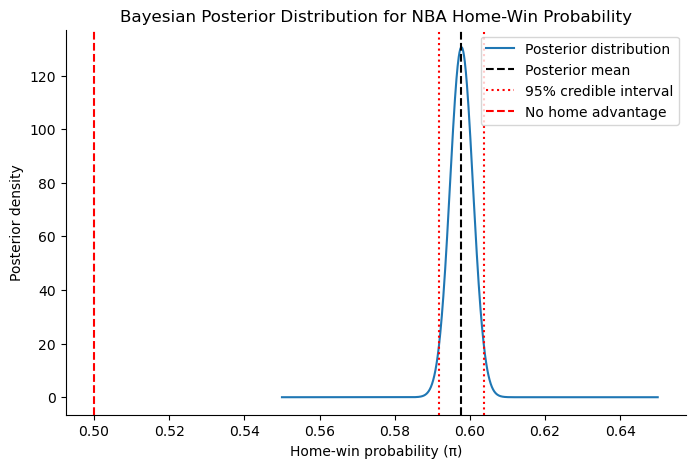

In [68]:
# posterior distribution
x = np.linspace(0.55, 0.65, 1000)
posterior_density = beta.pdf(x, alpha_post, beta_post)

plt.figure(figsize=(8, 5))
plt.plot(x, posterior_density, label="Posterior distribution") # distribution found 
plt.axvline(posterior_mean, linestyle="--", label="Posterior mean", color='black') # wins / total
# quantiles:
plt.axvline(credible_interval[0], linestyle=":", label="95% credible interval", color='red') # 0.25
plt.axvline(credible_interval[1], linestyle=":", color='red') # 0.75

plt.axvline(0.5, linestyle="--", label="No home advantage", color='red')

# icky spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xlabel("Home-win probability (π)")
plt.ylabel("Posterior density")
plt.title("Bayesian Posterior Distribution for NBA Home-Win Probability")
plt.legend()
plt.show()

For the Bayesian analysis, we modeled each regular season NBA game as a Bernoulli trial where a home win equals 1 and a home loss equals 0. The unknown parameter π represents the true long-run probability that the home team wins. 

We used a Beta(1,1) prior model with a uniform prior and represents limited prior knowledge about the value of π. After observing the data, the posterior distribution was updated using the number of home wins and losses (adding past real wins to the alpha and beta priors of 1 and 1). 

The posterior mean (around 0.598) was approximately equal to the frequentist estimate, and the 95% credible interval (around (0.592, 0.604)) was very close to the frequentist confidence interval. This shows that the large sample size of the data dominates the weak prior. 

Both frequentist and Naive analysis approaches support the conclusion that NBA teams have historically had a home-court advantage. This agreement indicates that the conclusion is robust and not sensitive to separate modeling assumptions.

## POSTERIOR PREDICTING

In [69]:
# posterior predictive: simulate future games
simulated_pi = beta.rvs(alpha_post, beta_post, size=10000) # means Random Variantes in sampling (rvs) - randomly generate beta distribution points
predicted_games = np.random.binomial(1, simulated_pi) # random samples from binomial distribution in simulated_pi (the simulated games)

print(f"Predicted home win rate (simulation): {predicted_games.mean()}") # proportion of wins on games sampled

Predicted home win rate (simulation): 0.5953


Using the posterior, we simulated future games based on the current games dataset and found that the predicted home-win rate reinforces our inference section above; the predicted rate of winning simulated games is around that 0.60, which is close to the pi estimate of 0.598 from the data from the inference section.

## Results

**Posterior Summary:** The posterior distribution for the home-win probability is Beta(15396, 10360), with a posterior mean of 0.5978. The 95% credible interval is (0.592, 0.604), indicating that the true home-win probability is tightly concentrated around 0.60. The posterior probability that π > 0.5 is effectively 1, providing strong evidence of a home-court advantage.

**Interpretation:** In the Bayesian framework, we interpret the credible interval as the range in which the true home-win probability lies with 95% probability, given the observed data and prior.  Since the entire interval lies well above 0.5 (0.592, 0.604), this indicates strong evidence that home teams win more often than away teams. Additionally, the posterior distribution is highly concentrated, reflecting low uncertainty due to the large sample size. These results closely align with the frequentist findings in section 3. This suggests that the conclusion of a home-court advantage is robust across different statistical approaches like frequentist vs Bayesian. The credible interval closely matches the frequentist confidence interval, reflecting the large sample size,=.

**Comparison to Frequentist Results:** These Bayesian results closely match the frequentist results from Section 3, as mentioned in interpretation. The posterior mean is almost the same as the maximum likelihood estimator (MLE), and the credible interval is nearly identical to the confidence interval. This agreement occurs because the dataset is large on NBA games, so the weak Beta(1,1) with alpha as 1 and Beta as 1, prior has very little influence on the posterior. Therefore, both approaches lead to the same conclusion, which is that the true home-win probability is meaningfully above 0.5.